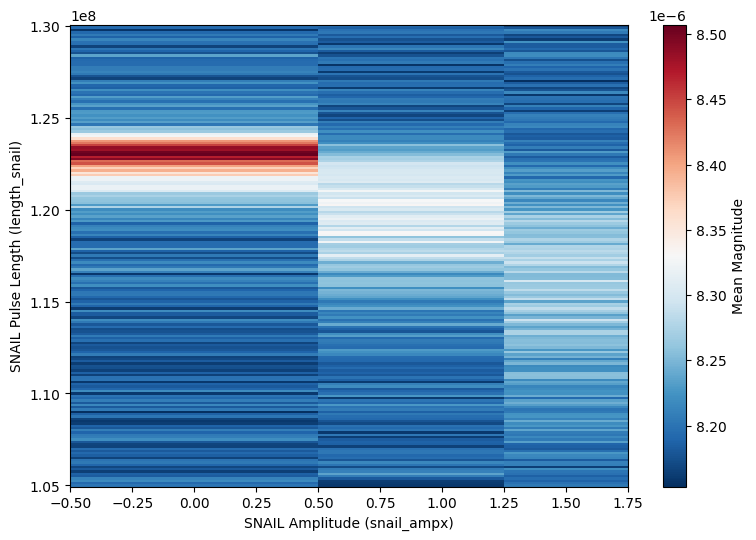

In [5]:
import h5py
import matplotlib.pyplot as plt
import numpy as np
import os

# Your specific directory
data_dir = r'C:\Users\qcrew2\Documents\Candace\eunice\data\2026-03-30'
file_name = '22-25-10_NumberSplitting.hdf5'
full_path = os.path.join(data_dir, file_name)


with h5py.File(full_path, 'r') as f:
    amp = f['cavity_drive_ampx'][:]      # Shape: (11,)
    qubit_frequency = f['qubit_frequency'][:] # Shape: (63,)
    raw_mag = f['Magnitude'][:]   # Shape: (5000, 11, 63)
    raw_I = f['I'][:]   # Shape: (5000, 11, 63)
    raw_Q = f['Q'][:]   # Shape: (5000, 11, 63)
    
    # Average over the 5000 time-trace points (axis 0)
    mag = np.mean(raw_mag, axis=0) # New Shape: (11, 63)
    I = np.mean(raw_I, axis=0) # New Shape: (11, 63)
    Q = np.mean(raw_Q, axis=0) # New Shape: (11, 63)

# Now check for transposition
# pcolormesh expects C to be (len(Y), len(X)) or for X/Y to match dimensions
if mag.shape == (len(amp), len(qubit_frequency)):
    mag = mag.T # Transpose to (63, 11) to match Y(63) and X(11)
    I = I.T # Transpose to (63, 11) to match Y(63) and X(11)
    Q = Q.T # Transpose to (63, 11) to match Y(63) and X(11)

plt.figure(figsize=(9, 6))
plt.pcolormesh(amp, qubit_frequency, mag, shading='auto', cmap='RdBu_r')
plt.colorbar(label='Mean Magnitude')
plt.xlabel('SNAIL Amplitude (snail_ampx)')
plt.ylabel('SNAIL Pulse Length (length_snail)')
plt.show()

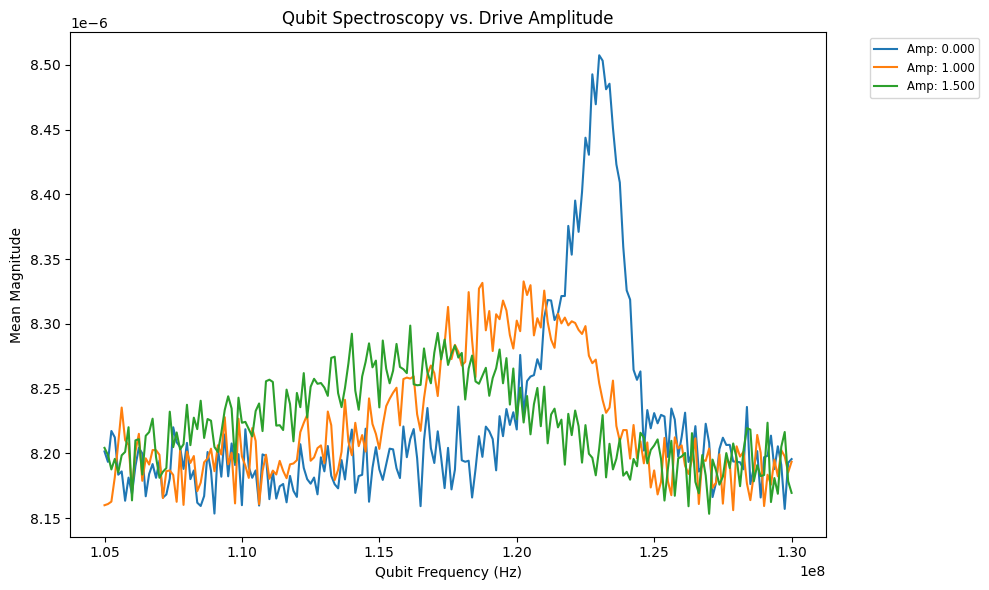

In [6]:
# Create a figure for the 1D plots
plt.figure(figsize=(10, 6))

# Since you transposed 'mag' to shape (63, 11), 
# the second axis (index 1) now corresponds to the 'amp' values.
num_amps = mag.shape[1]

for i in range(num_amps):
    # Extract the slice for this specific amplitude
    # mag[:, i] gives all frequency data for the i-th amplitude
    plt.plot(qubit_frequency, mag[:, i], label=f'Amp: {amp[i]:.3f}')

plt.title('Qubit Spectroscopy vs. Drive Amplitude')
plt.xlabel('Qubit Frequency (Hz)')
plt.ylabel('Mean Magnitude')

# If you have many amplitudes, the legend might be huge. 
# You can move it outside or only label a few.
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')
plt.tight_layout()
plt.show()

In [7]:
# Define the save path (using the same directory as your source)
save_path = os.path.join(data_dir, f'{file_name}_Processed_NumberSplitting.npz')

# Save multiple arrays into one compressed file
np.savez_compressed(
    save_path, 
    amp=amp, 
    qubit_frequency=qubit_frequency, 
    mag=mag, 
    I=I, 
    Q=Q
)

print(f"Data successfully saved to: {save_path}")

Data successfully saved to: C:\Users\qcrew2\Documents\Candace\eunice\data\2026-03-30\22-25-10_NumberSplitting.hdf5_Processed_NumberSplitting.npz


In [9]:
import numpy as np

# 1. Load the file
data = np.load(r'C:\Users\qcrew2\Documents\Candace\eunice\data\2026-03-30\22-25-10_NumberSplitting.hdf5_Processed_NumberSplitting.npz')

# 2. Extract arrays using the keys you used when saving
# (This assumes you saved them as 'amp', 'mag', etc.)
amp = data['amp']
qubit_frequency = data['qubit_frequency']
mag = data['mag']
I = data['I']
Q = data['Q']

# 3. Use the data
print(f"Loaded magnitude shape: {mag.shape}")

Loaded magnitude shape: (201, 3)
